In [19]:
## Exemplo 01
## Carregando os dados

url='/content/dados_doenca.txt'
dados_doenca<- read.table(url, header = TRUE, sep = "\t")

In [20]:
head(dados_doenca)

,ano,doenca,tm,ur
,<int>,<int>,<dbl>,<dbl>
1,1987,1,30.14,82.86
2,1988,0,30.66,79.57
3,1989,0,26.10,89.14
4,1990,1,28.43,91.00
5,1991,0,29.57,80.57
6,1992,1,31.25,67.82


In [21]:
# ajuste do modelo linear
reg_lin<-lm(doenca~tm+ur,data=dados_doenca)
summary(reg_lin)



Call:
lm(formula = doenca ~ tm + ur, data = dados_doenca)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8359 -0.1656  0.1292  0.2596  0.4109 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) -10.74306    4.80208  -2.237   0.0557 .
tm            0.28588    0.12031   2.376   0.0448 *
ur            0.03536    0.01897   1.864   0.0993 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4469 on 8 degrees of freedom
Multiple R-squared:  0.4143,	Adjusted R-squared:  0.2678 
F-statistic: 2.829 on 2 and 8 DF,  p-value: 0.1177


In [22]:
# Probabilidades de ter a doença no ano determinado
reg_lin$fitted

1          2          3          4          5          6          7 
 0.8036191  0.8359253 -0.1292359  0.6026376  0.5596835  0.5890570  0.1174565 
         8          9         10         11 
 0.9057419  0.2136531  0.8243142  0.6771478

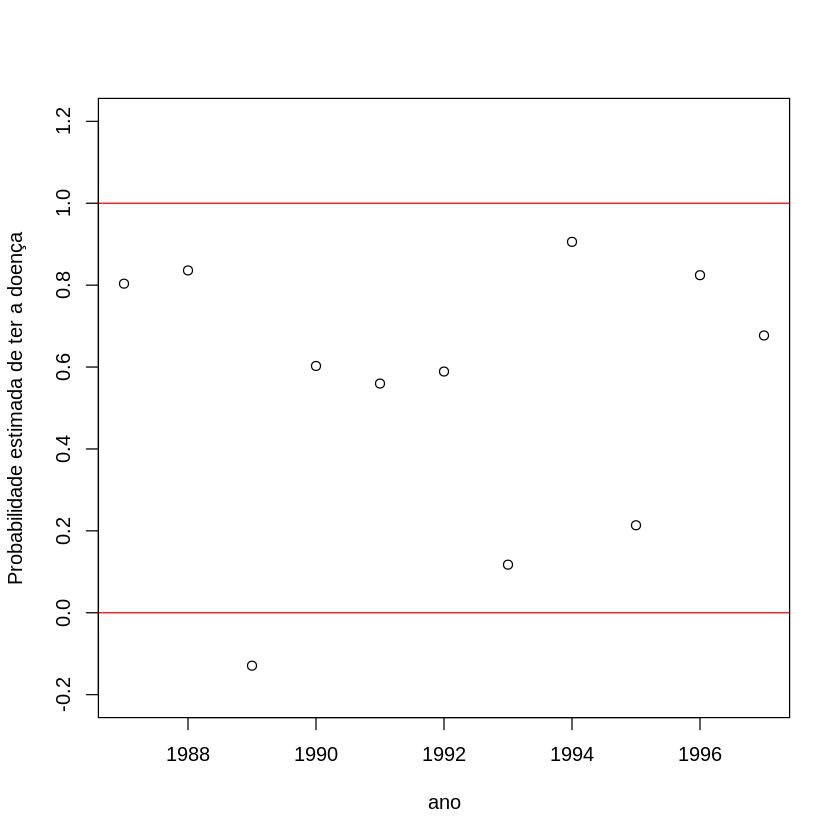

In [23]:
#  Gráfico (anos em função da probabilidades)
plot(dados_doenca$ano,reg_lin$fitted,xlab="ano",ylab="Probabilidade estimada de ter a doença",ylim=c(-0.2,1.2))
# Adicionando espaço paramétrico de probabilida
abline(h=0,col="red")
abline(h=1,col="red")


In [24]:
#Acessando medidas de qualidade
prob<-reg_lin$fitted.values

In [25]:
#Classificando em classes
reg_lin.classe<-ifelse(prob>0.5,1,0)
reg_lin.classe

1  2  3  4  5  6  7  8  9 10 11 
 1  1  0  1  1  1  0  1  0  1  1

In [26]:
# Tabela de confusão
tabela<-table(dados_doenca$doenca,reg_lin.classe)
tabela

   reg_lin.classe
    0 1
  0 3 2
  1 0 6

In [27]:
## Taxa de erro aparente
TEA=1-(sum(diag(tabela)))/sum(tabela)
TEA

[1] 0.1818182

In [28]:
## Acurácia

AC<-(sum(diag(tabela)))/sum(tabela)
AC

[1] 0.8181818

In [29]:
## Sensibilidade (verdadeiros positivos)
S<-tabela[2,2]/sum(tabela[2,])
S

[1] 1

In [30]:
## Especificidade (verdadeiros negativos)
E<-tabela[1,1]/sum(tabela[1,])


In [31]:
#  Modelo logit (não linearidade entre Y e variáveis explicativas)

logit<-glm(doenca~tm+ur,data=dados_doenca,family=binomial(link="logit"))
summary(logit)


Call:
glm(formula = doenca ~ tm + ur, family = binomial(link = "logit"), 
    data = dados_doenca)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept) -76.2042    47.7310  -1.597    0.110
tm            1.9776     1.2411   1.593    0.111
ur            0.2189     0.1502   1.457    0.145

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 15.1582  on 10  degrees of freedom
Residual deviance:  9.5121  on  8  degrees of freedom
AIC: 15.512

Number of Fisher Scoring iterations: 5


In [32]:
# valores de probabilidade estimados
prob<-logit$fitted.values

In [33]:
# Classificação
logit.classe<-ifelse(prob>0.5,1,0)
logit.classe


1  2  3  4  5  6  7  8  9 10 11 
 1  1  0  0  0  1  0  1  0  1  1

In [37]:
# Tabela de confusão
tabela1<-table(dados_doenca$doenca,logit.classe)
tabela1

   logit.classe
    0 1
  0 4 1
  1 1 5

In [36]:
## Taxa de erro aparente
TEA=1-(sum(diag(tabela1)))/sum(tabela1)
TEA

[1] 0.1818182

In [38]:
## Acurácia

AC<-(sum(diag(tabela1)))/sum(tabela1)
AC

[1] 0.8181818

In [39]:
## Sensibilidade (verdadeiros positivos)
S<-tabela1[2,2]/sum(tabela1[2,])
S

[1] 0.8333333

In [41]:
## Especificidade (verdadeiros negativos)
E<-tabela1[1,1]/sum(tabela1[1,])
E

[1] 0.8